# Лабораторная работа 5.4

Составные квадратурные формулы. Полное условие [здесь](differentiation_and_integration.md).

## Теоретическая часть

Базовая квадратурная формула строится на стандартном отрезке $[-1, 1]$ по узлам

$$
t_0 = -1, \quad t_1 = -\tfrac{1}{3}, \quad t_2 = \tfrac{1}{3}, \quad t_3 = +1.
$$

Это равномерная сетка с шагом $\tfrac{2}{3}$, поэтому соответствующая интерполяционная квадратурная формула — это формула Ньютона–Котеса (16.2.2 в учебнике).

Веса определяются интегралами от базисных многочленов Лагранжа:

$$
w_k = \int_{-1}^{1} L_k(t)\,dt, \qquad L_k(t) = \prod_{j \neq k} \frac{t - t_j}{t_k - t_j}.
$$

Прямое аналитическое вычисление дает

$$
w_0 = w_3 = \tfrac{1}{4}, \qquad w_1 = w_2 = \tfrac{3}{4}, \qquad w_0 + w_1 + w_2 + w_3 = 2.
$$

По теореме 16.3.1 из учебника, интерполяционная формула с $n$ узлами имеет алгебраическую точность не ниже $n - 1$. Для четырёх узлов алгебраическая точность равна $3$ (точность на кубических многочленах проверяется непосредственно, а на $t^4$ формула уже неточна). Локальная погрешность имеет порядок $O(h^5)$, а составная — порядок $O(h^4)$.

Перенос на отрезок $[a, b]$ выполняется заменой $x = \tfrac{a+b}{2} + \tfrac{b-a}{2} t$:

$$
\int_a^b f(x)\,dx \approx \frac{b - a}{2} \sum_{k=0}^{3} w_k\, f\!\left(\tfrac{a+b}{2} + \tfrac{b-a}{2} t_k\right).
$$

Составная формула получается разбиением $[a, b]$ на $N$ равных подотрезков длины $h = (b - a)/N$ и применением базовой формулы к каждому из них (п. 16.6 учебника).

Согласно правилу Рунге (п. 16.7 учебника), для метода порядка $p = 4$ при удвоении числа подотрезков

$$
I(f) - S_{2N}(f) \approx \frac{S_{2N} - S_N}{2^p - 1} = \frac{S_{2N} - S_N}{15}.
$$

Сгущение продолжается до тех пор, пока $|R_{2N}| = \bigl|(S_{2N} - S_N)/15\bigr|$ не станет меньше заданного $\mathrm{tol}$.

In [7]:
import math
import os
from collections.abc import Callable
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad


np.set_printoptions(precision=6, suppress=True)

ScalarFunction = Callable[[float], float]

REFERENCE_NODES = np.array([-1.0, -1.0 / 3.0, 1.0 / 3.0, 1.0], dtype=float)


@dataclass(frozen=True)
class CompositeQuadratureResult:
    """Результат вычисления интеграла составной квадратурной формулой."""

    integral_value: float
    subinterval_count: int
    runge_error_estimate: float
    refinement_history: list[tuple[int, float, float]]


def compute_reference_quadrature_weights(
    reference_nodes: np.ndarray = REFERENCE_NODES,
) -> np.ndarray:
    """Вычисляет веса базовой квадратуры на [-1, 1] через интегралы Лагранжа."""
    nodes_array = np.asarray(reference_nodes, dtype=float)
    node_count = nodes_array.size
    weights = np.zeros(node_count, dtype=float)

    for node_index in range(node_count):
        current_node = nodes_array[node_index]
        other_nodes = np.delete(nodes_array, node_index)
        denominator = float(np.prod(current_node - other_nodes))

        def lagrange_basis_polynomial(
            t: float,
            other_nodes_local: np.ndarray = other_nodes,
            denominator_local: float = denominator,
        ) -> float:
            return float(np.prod(t - other_nodes_local) / denominator_local)

        integral_value, _ = quad(
            lagrange_basis_polynomial,
            -1.0,
            1.0,
            epsabs=1e-12,
            epsrel=1e-12,
            limit=200,
        )
        weights[node_index] = integral_value

    return weights


def evaluate_composite_quadrature_on_uniform_grid(
    function: ScalarFunction,
    interval: tuple[float, float],
    subinterval_count: int,
    reference_nodes: np.ndarray,
    reference_weights: np.ndarray,
) -> float:
    """Считает интеграл составной квадратурой на равномерной сетке."""
    if subinterval_count < 1:
        raise ValueError("Число подотрезков должно быть положительным.")

    left_endpoint, right_endpoint = map(float, interval)
    subinterval_length = (right_endpoint - left_endpoint) / subinterval_count
    half_length = 0.5 * subinterval_length

    integral_value = 0.0
    for subinterval_index in range(subinterval_count):
        midpoint = left_endpoint + (subinterval_index + 0.5) * subinterval_length
        local_sum = 0.0
        for node_index in range(reference_nodes.size):
            sample_point = midpoint + half_length * reference_nodes[node_index]
            local_sum += reference_weights[node_index] * float(function(sample_point))
        integral_value += half_length * local_sum

    return integral_value


def integrate_with_composite_quadrature_rule(
    function: ScalarFunction,
    interval: tuple[float, float],
    tolerance: float,
    initial_subinterval_count: int = 1,
    maximum_subinterval_count: int = 2**22,
) -> CompositeQuadratureResult:
    """Сгущает сетку до выполнения условия по правилу Рунге."""
    if tolerance <= 0.0:
        raise ValueError("Точность tol должна быть положительной.")
    if initial_subinterval_count < 1:
        raise ValueError("Начальное число подотрезков должно быть положительным.")

    reference_weights = compute_reference_quadrature_weights()
    method_order = 4
    runge_denominator = float(2**method_order - 1)

    current_subinterval_count = initial_subinterval_count
    current_integral_value = evaluate_composite_quadrature_on_uniform_grid(
        function,
        interval,
        current_subinterval_count,
        REFERENCE_NODES,
        reference_weights,
    )

    refinement_history: list[tuple[int, float, float]] = [
        (current_subinterval_count, current_integral_value, math.inf),
    ]

    while True:
        refined_subinterval_count = current_subinterval_count * 2
        if refined_subinterval_count > maximum_subinterval_count:
            raise RuntimeError("Достигнут предел числа подотрезков без выполнения tol.")

        refined_integral_value = evaluate_composite_quadrature_on_uniform_grid(
            function,
            interval,
            refined_subinterval_count,
            REFERENCE_NODES,
            reference_weights,
        )
        runge_error_estimate = (
            refined_integral_value - current_integral_value
        ) / runge_denominator
        refinement_history.append(
            (
                refined_subinterval_count,
                refined_integral_value,
                abs(runge_error_estimate),
            )
        )

        if abs(runge_error_estimate) < tolerance:
            return CompositeQuadratureResult(
                integral_value=refined_integral_value,
                subinterval_count=refined_subinterval_count,
                runge_error_estimate=abs(runge_error_estimate),
                refinement_history=refinement_history,
            )

        current_subinterval_count = refined_subinterval_count
        current_integral_value = refined_integral_value

## Экспериментальная часть

Сначала проверяем веса базовой формулы и сравниваем с аналитическими значениями $w_0 = w_3 = 1/4$, $w_1 = w_2 = 3/4$.

Затем для гладкой тестовой функции

$$
f(x) = e^{x} \cos(2 x), \qquad x \in [0, 3],
$$

вычисляем интеграл составной формулой при $\mathrm{tol} = 2^{-5}, 2^{-10}, \dots, 2^{-40}$ и строим график зависимости $\mathrm{tol}$ от числа подотрезков $N$ в логарифмической шкале. Теоретическая зависимость для метода порядка $p = 4$ имеет вид $\mathrm{tol} \sim N^{-4}$, поэтому в логарифмических координатах ожидается прямая с наклоном $-4$.

In [8]:
computed_reference_weights = compute_reference_quadrature_weights()
analytic_reference_weights = np.array([0.25, 0.75, 0.75, 0.25], dtype=float)

print("Узлы базовой формулы:", REFERENCE_NODES)
print("Вычисленные веса:    ", computed_reference_weights)
print("Аналитические веса:  ", analytic_reference_weights)
print(
    "Максимум |w_num - w_ref| = "
    f"{np.max(np.abs(computed_reference_weights - analytic_reference_weights)):.3e}"
)
print(f"Сумма весов = {computed_reference_weights.sum():.12f} (ожидается 2)")


def target_function(x: float) -> float:
    """Гладкая тестовая функция для составной квадратуры."""
    return math.exp(x) * math.cos(2.0 * x)


integration_interval = (0.0, 3.0)
reference_integral_value, _ = quad(
    target_function,
    integration_interval[0],
    integration_interval[1],
    epsabs=1e-12,
    epsrel=1e-12,
    limit=400,
)
print()
print(f"Эталонное значение интеграла (scipy.quad) = {reference_integral_value:.12f}")

tolerance_exponents = list(range(5, 45, 5))
tolerance_values = [2.0 ** (-exponent) for exponent in tolerance_exponents]

subinterval_counts: list[int] = []
actual_absolute_errors: list[float] = []

print()
print("  tol            N       |I_num - I_ref|     оценка Рунге")
for tolerance_value in tolerance_values:
    quadrature_result = integrate_with_composite_quadrature_rule(
        target_function,
        integration_interval,
        tolerance_value,
    )
    actual_absolute_error = abs(
        quadrature_result.integral_value - reference_integral_value
    )
    subinterval_counts.append(quadrature_result.subinterval_count)
    actual_absolute_errors.append(actual_absolute_error)
    print(
        f"  {tolerance_value:.3e}   {quadrature_result.subinterval_count:6d}   "
        f"{actual_absolute_error:.3e}        {quadrature_result.runge_error_estimate:.3e}"
    )

Узлы базовой формулы: [-1.       -0.333333  0.333333  1.      ]
Вычисленные веса:     [0.25 0.75 0.75 0.25]
Аналитические веса:   [0.25 0.75 0.75 0.25]
Максимум |w_num - w_ref| = 2.220e-16
Сумма весов = 2.000000000000 (ожидается 2)

Эталонное значение интеграла (scipy.quad) = 1.412223026619

  tol            N       |I_num - I_ref|     оценка Рунге
  3.125e-02        2   1.807e-01        2.204e-02
  9.766e-04        8   6.541e-04        6.720e-04
  3.052e-05       32   2.533e-06        2.538e-06
  9.537e-07       64   1.582e-07        1.583e-07
  2.980e-08      128   9.889e-09        9.891e-09
  9.313e-10      256   6.181e-10        6.181e-10
  2.910e-11     1024   2.411e-12        2.414e-12
  9.095e-13     2048   1.439e-13        1.512e-13


Наклон зависимости log(tol) от log(N): -3.5994 (теоретическое значение -4)


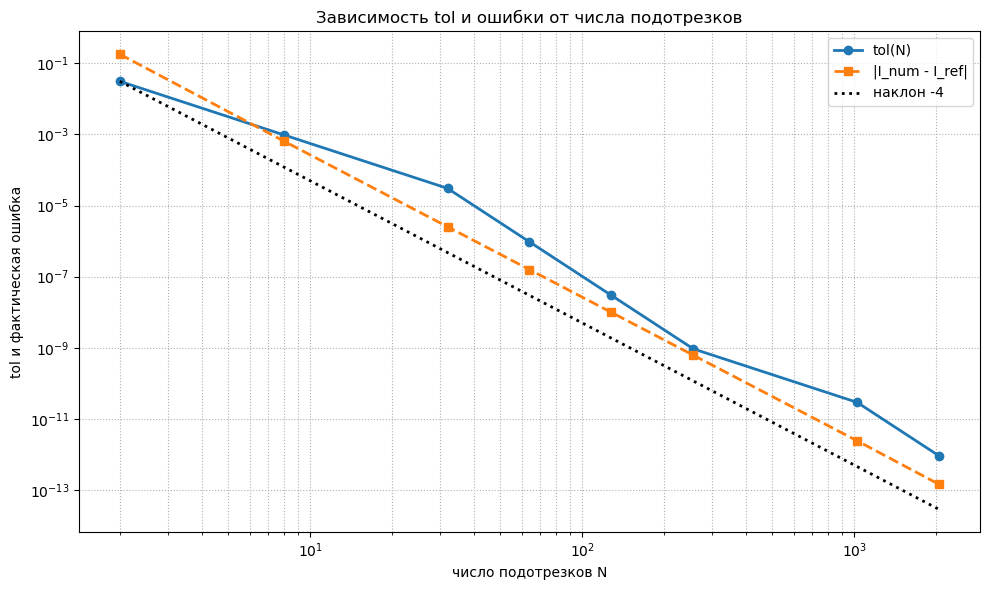

In [9]:
subinterval_counts_array = np.array(subinterval_counts, dtype=float)
tolerance_values_array = np.array(tolerance_values, dtype=float)
actual_absolute_errors_array = np.array(actual_absolute_errors, dtype=float)

log_subinterval_counts = np.log(subinterval_counts_array)
log_tolerance_values = np.log(tolerance_values_array)
fit_slope, fit_intercept = np.polyfit(
    log_subinterval_counts,
    log_tolerance_values,
    1,
)
print(
    "Наклон зависимости log(tol) от log(N): "
    f"{fit_slope:.4f} (теоретическое значение -4)"
)

theoretical_reference_line = tolerance_values_array[0] * (
    subinterval_counts_array / subinterval_counts_array[0]
) ** (-4)

plt.figure(figsize=(10, 6))
plt.loglog(
    subinterval_counts_array,
    tolerance_values_array,
    marker="o",
    linewidth=2.0,
    label="tol(N)",
)
plt.loglog(
    subinterval_counts_array,
    actual_absolute_errors_array,
    marker="s",
    linestyle="--",
    linewidth=2.0,
    label="|I_num - I_ref|",
)
plt.loglog(
    subinterval_counts_array,
    theoretical_reference_line,
    linestyle=":",
    linewidth=2.0,
    color="black",
    label="наклон -4",
)
plt.xlabel("число подотрезков N")
plt.ylabel("tol и фактическая ошибка")
plt.title("Зависимость tol и ошибки от числа подотрезков")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

## Вывод

Веса базовой квадратурной формулы с узлами $-1, -1/3, 1/3, 1$, полученные численно через интегралы базисных многочленов Лагранжа, совпадают с аналитическими значениями $\tfrac{1}{4}, \tfrac{3}{4}, \tfrac{3}{4}, \tfrac{1}{4}$. Сумма весов равна $2$, что согласуется с длиной отрезка $[-1, 1]$. Составная квадратурная формула со сгущением сетки и контролем по правилу Рунге для гладкой функции дает ошибку, монотонно убывающую с ростом $N$. Наклон зависимости $\log(\mathrm{tol})$ от $\log(N)$ численно близок к $-4$, что соответствует теоретическому порядку аппроксимации $p = 4$ для четырехузловой закрытой формулы Ньютона–Котеса.